In [1]:
import polars as pl
import numpy as np
from pathlib import Path
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ANALYZED_PARQUET_PATH = PROJECT_ROOT / "data/processed/analyzed_yellow_taxi.parquet"

In [3]:
analyzed_lf = pl.scan_parquet(ANALYZED_PARQUET_PATH)
analyzed_lf.head(5).collect()

tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,total_amount,month_name
datetime[μs],datetime[μs],i32,f32,i32,i32,f32,str
2025-03-31 08:25:18,2025-03-31 08:31:33,1,0.92,164,233,13.65,"""March"""
2025-03-31 08:35:17,2025-03-31 08:56:30,1,10.55,229,138,59.59,"""March"""
2025-03-31 08:45:27,2025-03-31 08:59:43,1,2.8,79,162,20.65,"""March"""
2025-03-31 08:12:55,2025-03-31 08:21:41,1,1.5,263,163,19.35,"""March"""
2025-03-31 08:21:32,2025-03-31 08:33:03,1,1.57,224,186,18.0,"""March"""


In [4]:
an_pl_df = analyzed_lf.collect(engine="streaming")

Make the columns binary and ensure the model can properly "understand" time

In [5]:
df_pl = an_pl_df.with_columns([
    (pl.col('passenger_count') >=2).cast(pl.Int8).alias("is_multi"),
    pl.col("tpep_pickup_datetime").cast(pl.Datetime("us"), strict=False),
]).with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("pickup_dow"),
]).with_columns([
    (pl.col("pickup_dow").is_in([5,6])).cast(pl.Int8).alias("is_weekend"),

    (pl.col("pickup_hour").cast(pl.Float32)
    .map_elements(lambda h: np.sin(2 * np.pi * h/24.0))
    .alias("pickup_hour_sin")),
    (pl.col("pickup_hour").cast(pl.Float32)
    .map_elements(lambda h: np.cos(2 * np.pi * h/24.0))
    .alias("pickup_hour_cos")),
])

In [6]:
feature_cols = [
    "pickup_hour_sin", "pickup_hour_cos",
    "pickup_dow", "is_weekend",
    "trip_distance", "total_amount",
    "PULocationID"
]

target_col = "is_multi"

In [7]:
df_small = df_pl.select(feature_cols + [target_col])
df_pd = df_small.to_pandas()

X = df_pd[feature_cols]
y = df_pd[target_col]


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' t

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_features = feature_cols

# Logistic regression (with gradient-based solvers) converges more reliably when inputs are on comparable scales.
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

log_reg = LogisticRegression(
    l1_ratio=0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

ROC AUC:  0.5998477812629393

PR AUC (for multi-passenger):  0.25919607350376317

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.57      0.68   5665361
           1       0.25      0.57      0.35   1399285

    accuracy                           0.57   7064646
   macro avg       0.55      0.57      0.51   7064646
weighted avg       0.73      0.57      0.62   7064646



<Axes: >

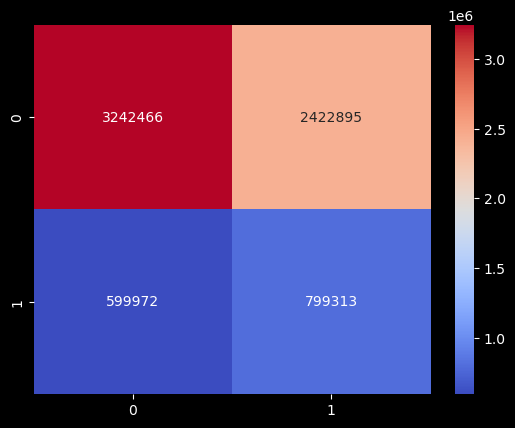

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

y_val_pred = clf.predict(X_val)
y_val_proba = clf.predict_proba(X_val)[:, 1]

print("ROC AUC: ",roc_auc_score(y_val, y_val_proba))
print("\nPR AUC (for multi-passenger): ",average_precision_score(y_val, y_val_proba))

print("\nClassification report:\n",classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, cmap="coolwarm", fmt='d')

the behavior at threshold 0.5 is:

Very aggressive in calling trips multi → high recall for multi, but massive number of false multi alarms.

This is consistent with class_weight='balanced' pushing the model to care about the minority, plus the skewed data and the particular decision boundary.

Given singles are the majority, 0.57 accuracy is actually worse than a dumb baseline that predicts “single” for everyone:

That baseline would get accuracy ≈ 80% (since ~80% are singles).

So in terms of hard labels at threshold 0.5, your classifier is doing worse than always predicting class 0, because it is trying to capture the minority class aggressively.

tuning threshold, think about what to care about via precision vs recall for single vs multi.... maybe the baseline

So we're gonna first tune that threshold=0.5 to prioritise high precision for multi whilst keeping recall tolerable...

In [ ]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

In [ ]:
thresholds = np.linspace(0.0, 1.0, 101)

results = []

# y_val_proba is a 1D array of predicted probabilities for the positive class
# confident enough (probability ≥ t) that the trip is multi-passenger.

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
 # If the model never predicts class 1 at this threshold, skip (precision undefined)
    if y_pred_t.sum() == 0:
        continue

    prec = precision_score(y_val, y_pred_t, pos_label=1)
    rec = recall_score(y_val, y_pred_t, pos_label=1)
    results.append((t, prec, rec))

In [ ]:
target_precision = 0.4

In [ ]:
res_df = pd.DataFrame(results, columns=["threshold", "precision", "recall"])

good = res_df[res_df["precision"] >= target_precision]

if good.empty:
    print("No threshold achieves the desired precision. Try lowering target_precision.")
else:
    best = good.sort_values("recall", ascending=False).iloc[0]
    print(best)
    best_threshold = best["threshold"]
    print("Chosen threshold:", best_threshold)

threshold    0.760000
precision    0.402533
recall       0.004203
Name: 76, dtype: float64
Chosen threshold: 0.76


Definitely not worth it!... i'll need to try another model maybe since i doubt i could make the features any better than they are now. But i think let's first tune Logisitc Regression some more... like via class_weights and regularization

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE # to improve recall on minority class
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score # wraps a metric into a scorer object that GridSearchCV can use
from scipy.stats import loguniform

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE()), # will be overridden by param distributions
    ("clf", LogisticRegression(
        solver="saga", # supports l1, l2, and elasticnet penalties on large datasets.
        class_weight="balanced",
        max_iter=5000 # ensure has enough iterations to converge, especially with elastic net and imbalanced data.
    ))
])

param_distributions = {
    "smote": [SMOTE(random_state=42), "passthrough"],
    "clf__C": loguniform(1e-3, 1e2),
    "clf__penalty": ["l1", "l2", "elasticnet"],
    "clf__l1_ratio": [0.2, 0.5, 0.8],
}

# call predict_proba (or decision_function) and pass those probabilities to the metric.” average_precision_score needs probability scores, not class labels.
scorer = make_scorer(average_precision_score, needs_proba=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=scorer,
    cv=cv,
    n_jobs=1,  # avoid worker pickling/temp-file usage (disk-full caused PicklingError)
    refit=True,
    random_state=42,
    verbose=2,
)

I'm gonna need to find a way to offload this grid search stuff somewhere else or find a way to clear some memory...

Considering that this is a fairly large datset, I think let's try Randomized CV

In [ ]:
rand_search.fit(X_train, y_train)

print(rand_search.best_params_)
best_pipe = rand_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


Grid search is done... i think i will do BOTH saving the best model and saving the best parameters(just in case I use new features(hence new data))

In [ ]:
import joblib
import json

best_model = rand_search.best_estimator_
best_params = rand_search.best_params_

print("Best params found: ",best_params)

with open("logreg_smote_best_params.json", "w") as f:
    json.dump(best_params, f)
print("Saved best params to logreg_smote_best_params.json")

joblib.dump(best_model, "logreg_smote_best_model.joblib")
print("Saved best model to logreg_smote_best_model.joblib")

Currently facing a challenge of compute... even Colab was of no help to me! I may need to use the machines at the university. For now i will test with another model since that's what i would have done either way! For now let's try out GBTs...

In [15]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score

In [16]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

In [17]:
params={
"objective":"binary",
"metric":["auc","binary_logloss"],
"boosting_type":"gbdt",
"learning_rate":0.05,
"num_leaves":31,
"max_depth":-1,
"feature_fraction":0.8,
"bagging_fraction":0.8,
"bagging_freq":5,
"lambda_l1":0.1,
"lambda_l2":0.2,
"min_data_in_leaf":20,
"verbose":-1
}

In [ ]:
model=lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(50)]
)

Training until validation scores don't improve for 50 rounds


In [ ]:
y_pred_proba = model.predict(X_val, num_iteration=model.best_iteration)
y_pred = (y_pred_proba > 0.5).astype(int)

In [ ]:
accuracy=accuracy_score(y_val,y_pred)
precision=precision_score(y_val,y_pred)
recall=recall_score(y_val,y_pred)
f1=f1_score(y_val,y_pred)
auc=roc_auc_score(y_val,y_pred_prob)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("AUC:",auc)

In [ ]:
print(classification_report(y_val, y_pred))

In [ ]:
importance=pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importance()
}).sort_values(by="importance", ascending=False)

sns.barplot(x="importance", y="feature", data=importance)
plt.title("Top features")
plt.show()

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in kf.split(X,y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_set = Dataset(X_tr, label=y_tr)
    val_set = Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        train_set,
        num_boost_round=500,
        valid_sets=[val_set],
        callbacks=[
            lgb.early_stopping(30),
            lgb.log_evaluation(0)
        ]
    )

    preds = model.predict(X_val)
    scores.append(roc_auc_score(y_val, preds))

print("CV AUC: "np.mean(scores))

XGBoost Implemenation

In [ ]:
from sklearn.metrics import accuracy_score
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X["PULocationID"] = X["PULocationID"].astype('category')

In [ ]:
xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(X_val, y_val, enable_categorical=True)

In [ ]:
params = {
    'objective': 'binary:logistic',
    'max_depth': 3,
    'learning_rate': 0.1,
}
n=50
model = xgb.train(params=params, dtrain=xgb_train, num_boost_round=n)

In [ ]:
preds = model.predict(xgb_test)
preds = np.round(preds)
accuracy = accuracy(y_test, preds)
print('Accuracy of the mode is: ',accuracy*100)